In [11]:
import os, sys, subprocess
sys.path.append(os.path.join(os.environ.get('IDEFIX_DIR','../../../../'), 'pytools'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import dump_io as io

import pickle as pk
from astropy import constants as const, units as u

from scipy.integrate import solve_ivp

%matplotlib inline


In [12]:
uL = u.AU.cgs
uv = (const.GM_sun/u.AU)**0.5
ud = 1.0*u.g.cgs/u.cm.cgs**3
uM = ud*uL**3
ut = (uL/uv).decompose()
uT = ((u.g.cgs/u.mol.cgs) * uv**2 / (const.k_B.cgs * const.N_A.cgs)).decompose()
u_opac = (1/(ud*uL)).decompose()

mu = 2.353

u_aR = (uM*uv**2/(uL**3 * uT**4)).decompose()
a_rad = ((4*const.sigma_sb/const.c)/u_aR).to_value()

c_l = (const.c / uv).decompose().to_value()
print(c_l, a_rad, 1/ut, u_opac)

10065.320121972596 1.1052816266437602e-07 1.990983674453926e-07 1 / s 6.684587122268446e-15 m2 / kg


In [13]:
class RadiativeDustyWave:
    """FLD for dust+gas temperatures coupled by radiation and collisions"""

    def __init__(self, rho_g, T, cd, cg, kapp, mu=2.353, eps=0.01, a_d=(0.1*u.cm.cgs/uL).to_value(), alpha=1, L=1):

        cs2 = T/mu # k/mH = 1 in code units
        cs = np.sqrt(cs2)

        Er = a_rad * T**4
        rho_d = rho_g*eps

        gamma = np.sqrt(1.4)*cs/a_d

        self.E_rad = Er 
        self.T = T 
        self.rho = rho_g
        self.eps = eps 
        self.cs2 = cs2

        # Compute the eigenvectors and eigenvalues

        ug = cg*T
        ud = cd*T

        Q = c_l *kapp

        ag = alpha*gamma*cg

        Ik = 1j * cs * 2*np.pi/L
        nu = c_l/(3*rho_g*kapp*(1+eps)*cs2)

        M = [[  0  ,     -Ik     ,           0          ,0,      0      ,          0         ,          0                   ], # rho_g
             [ -Ik , -gamma*rho_d,          -Ik         ,0, +gamma*rho_d,          0         ,          0                   ], # v_g
             [  0  , -Ik*cs2/ug  , -(4*Q*Er+ag*rho_d)/ug,0,      0      ,      ag*rho_d/ug   ,      Q*Er/ug                 ], # T_g
             [  0  ,      0      ,           0          ,0,     -Ik     ,          0         ,          0                   ], # rho_d
             [  0  , +gamma*rho_g,           0          ,0,-gamma*rho_g,           0         ,          0                   ], # v_d
             [  0  ,      0      ,       ag*rho_g/ud    ,0,      0     ,-(4*Q*Er+ag*rho_g)/ud,      Q*Er/ud                 ], # T_d
             [  0  ,      0      ,        4*Q*rho_g     ,0,      0     ,       4*Q*rho_d     , -(Q*rho_g+Q*rho_d) + nu*Ik*Ik], # E_r
        ]

        l, v = np.linalg.eig(M)

        # Add the dust density:
        v = v.T 

        self._l = l 
        self._v = v
        self._v0 = np.array([rho_g, cs, T, rho_d, cs, T, Er])[:,None]

        self._Ik = 1j * 2*np.pi/L

        """
        dt = 3.092482e-02

        lg = dt*c_l*rho_g*kapp*a_rad*T**3
        ld = dt*c_l*rho_d*kapp*a_rad*T**3

        fE = - 3*lg*T - 3*np.sum(ld*T)

        g = ag*rho_g*rho_d*dt
        
        Zd = (rho_d*cd + 4*ld + g)
        Zg = (rho_g*cg + 4*lg + np.sum((rho_d*cd + 4*ld)*g/Zd))

        k_tot = rho_g*kapp + np.sum(rho_d*kapp*g/Zd)
        c_tot = rho_g*cg   + np.sum(rho_d*cd*g/Zd)
        u_tot = rho_g*cg*T + 3*lg*T + np.sum((rho_d*cd*T + 3*ld*T)*g/Zd)
        l_tot =   lg       + np.sum(ld*g/Zd)

        print(g, ld, lg)
        print(Zg, Zd)
        print(k_tot, c_tot, u_tot, l_tot)

        RHS = a_rad*T**4 + fE + np.sum(4*ld*(rho_d*cd*T + 3*ld*T)/Zd) + 4*l_tot*u_tot/Zg
 
        NORM = 1 + c_l*dt*(np.sum(rho_d*kapp*rho_d*cd/Zd) + k_tot*c_tot/Zg)

        print(RHS, NORM, RHS/NORM, a_rad*T**4)
        """

    @property
    def eigenvalues(self):
        return self._l 
    
    @property
    def eigenvectors(self):
        return self._v

    def solution(self, amplitudes, time, pos=0):
        l, t = np.meshgrid(self._l, time, indexing='ij')
        
        A = amplitudes[:,None] * np.exp(l*t - self._Ik*pos)

        sol = np.dot(self._v.T, A)
        return sol


[ 0.00000000e+00+0.00000000e+00j -7.31847498e+07-7.85878655e-12j
 -1.60848485e+05+2.84585715e-12j -1.95426948e+03-6.24607970e-15j
 -6.80510630e-03-7.50582589e-02j -6.80510637e-03+7.50582590e-02j
 -6.29830958e-02-1.05126171e-10j]
[ 0.27707158-3.08473436e-01j -0.33335003+3.09651137e-01j
  0.12184642+5.75202410e-05j  0.27706058-3.08485269e-01j
 -0.33333919+3.09665157e-01j  0.12184642+5.75201153e-05j
  0.46082262+2.17326245e-04j]


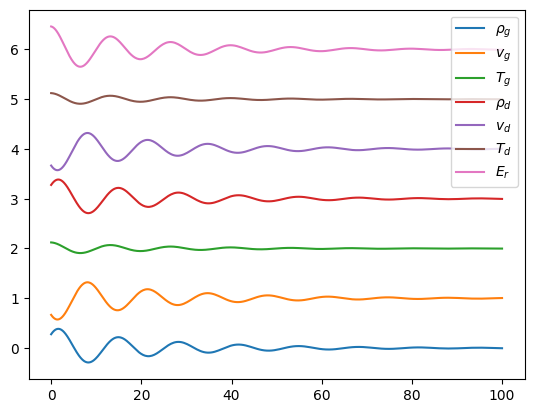

In [14]:
rho = 1e-12 # g/cm**3 (is already code units)
T = float(30 *u.K.cgs/uT) #
k = float(1 * ((u.cm.cgs**2/u.g.cgs) / u_opac).decompose())
a = float(1e-4 * (u.cm.cgs / uL).decompose()) 

RDW = RadiativeDustyWave(rho, T, 0.1, 2.5/mu, k, a_d=a)

print(RDW.eigenvalues)

A = np.zeros(7)
A[RDW.eigenvalues.imag.argmax()] = 1

times = np.geomspace(1e-3, 100, 1000)
sol = RDW.solution(A, times*2*np.pi)
print(sol[:,0])

labels = [r'$\rho_g$', '$v_g$', '$T_g$', r'$\rho_d$', '$v_d$', '$T_d$', '$E_r$']

for i in range(7):
    plt.plot(times, sol[i].real + i, label=f'{labels[i]}')
plt.legend()

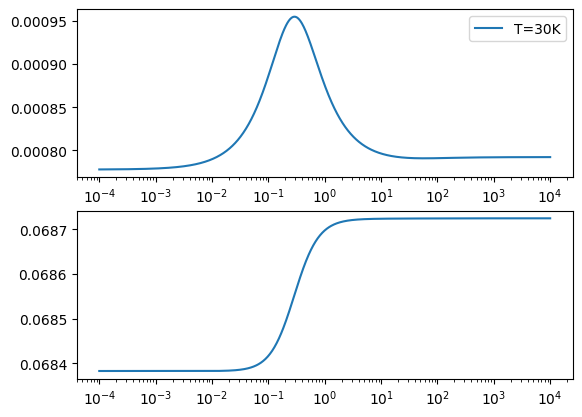

In [15]:
size = np.geomspace(1e-4, 1e4, 1000)

f, ax = plt.subplots(2)

for TK in [30]:
    w = []
    T = float(TK *u.K.cgs/uT) #

    for a in size:
        a = float(a * (u.cm.cgs / uL).decompose()) 
        RDW = RadiativeDustyWave(1e-13, T, 0.1, 2.5/mu, k, a_d=a)

        w.append(RDW.eigenvalues[RDW.eigenvalues.imag.argmax()])
    w = np.array(w)

    ax[0].semilogx(size, -w.real, label=f'T={TK}K')
    ax[1].semilogx(size, w.imag)
ax[0].legend()



6.684587122268446e-15
6.684587122268446e-18


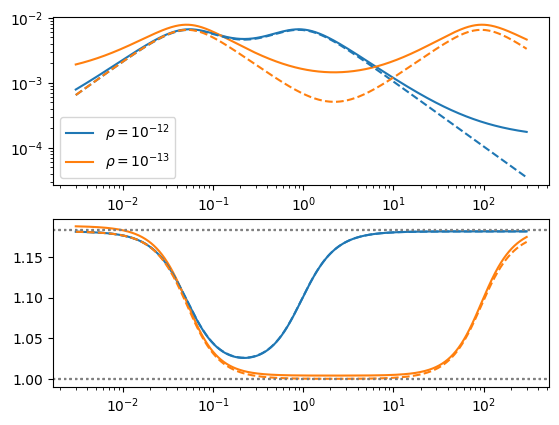

In [16]:
kappas = np.geomspace(3e-3, 3e2, 1000)
f, ax = plt.subplots(2)

TK = 30
eps = 0.1
for a, ls in zip([0.1, 1e-4], ['-', '--']):
    a = float(a* (u.cm.cgs / uL).decompose()) 
    print(a)
    for rho, c in zip([1e-12, 1e-13], ['C0', 'C1']):
        w = []
        T = float(TK *u.K.cgs/uT) #

        for k in kappas:
            k = float(k * ((u.cm.cgs**2/u.g.cgs) / u_opac).decompose())

            RDW = RadiativeDustyWave(rho, T, 0.1, 2.5/mu, k, a_d=a, eps=eps)

            w.append(RDW.eigenvalues[RDW.eigenvalues.imag.argmax()])
        w = np.array(w)

        label = None
        if ls == '-':
            label = r'$\rho=10^{'+f'{int(np.log10(rho))}' +'}$'

        ax[0].loglog(kappas, -w.real, c=c, ls=ls, label=label)
        ax[1].semilogx(kappas, w.imag*np.sqrt(mu*(1+eps)/T)/(2*np.pi), c=c, ls=ls)
        ax[1].axhline(1.0, ls=':', c='0.5')
        ax[1].axhline(1.4**0.5, ls=':', c='0.5')

ax[0].legend()



In [17]:
def get_name(rho0, a0, kappa0):
    return f'{np.log10(rho0)}_{np.log10(a0)}_{np.log10(kappa0)}'

def run_model(rho0, a0, kappa0, dt_out=100):
    kappa = float(kappa0 * ((u.cm.cgs**2/u.g.cgs) / u_opac).decompose())
    a = float(a0 * (u.mm.cgs / uL).decompose()) 
    T = float(30 *u.K.cgs/uT)
    eps = 0.1

    # Get the initial conditions
    RDW = RadiativeDustyWave(rho0, T, 0.1, 2.5/mu, kappa, a_d=a, eps=eps)
        
    A = np.zeros(7)
    A[RDW.eigenvalues.imag.argmax()] = 1
    IC = RDW.solution(A, 0)[:,0]

    name = get_name(rho0, a0, kappa0)

    # Write the input file
    ini = ''
    block = None
    ini_file = f'out/{name}/idefix_{name}.ini'
    with open('template.ini', 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('[') and line.endswith(']'):
                block = line[1:-1]
            if block == 'Dust':
                if line.startswith('drag             size'):
                    line = f'drag             size  {a}'
            elif block == 'Radiation':
                if line.startswith('kappaP constant'):
                    line = f'kappaP constant {kappa0} {kappa0}'
                elif line.startswith('kappaR constant'):
                    line = f'kappaR constant {kappa0} {kappa0}'
            elif block == 'Setup':
                if   line.startswith('rho      '):
                    line = f'rho      {rho0}'
                elif line.startswith('d2g      '):
                    line = f'd2g      {eps}'
                elif line.startswith('drho     '):
                    line = f'drho     {IC[0].real} {IC[0].imag} {IC[3].real} {IC[3].imag}'
                elif line.startswith('dvel     '):
                    line = f'dvel     {IC[1].real} {IC[1].imag} {IC[4].real} {IC[4].imag}'
                elif line.startswith('dTmp     '):
                    line = f'dTmp     {IC[2].real} {IC[2].imag} {IC[5].real} {IC[5].imag}'
                elif line.startswith('dEr      '):
                    line = f'dEr      {IC[6].real} {IC[6].imag}'
            elif block == 'Output':
                if line.startswith('dmp_dir'):
                    line = f'dmp_dir out/{name}'
                elif line.startswith('dmp'):
                    line = f'dmp {dt_out}'
            ini += line + '\n'
    
    os.makedirs(f'out/{name}',exist_ok=True)
    with open(ini_file, 'w') as f:
        print(ini, file=f)
    
    subprocess.run(['./idefix', '-i', ini_file])

def fit_eigenvalues(data, field=1):

    def f(t, *par):
        return par[0] + par[1] * np.exp(par[2]*t) * np.cos(par[3]*t - par[4])

    from scipy.optimize import curve_fit
    
    
    w = 2*np.pi*np.sqrt(T/mu)
    a0 = data[:, field+1].mean()
    amp = 0.5*(data[:, field+1].max()-data[:,field+1].min())

    popt, pcov = curve_fit(f, data[:,0], data[:, field+1], p0=[a0,amp,-0.01,w,0])
    return popt[2] + 1j*popt[3], f(data[:,0], *popt)

def plot_model(rho0, a0, kappa0, fit=False):
    kappa = float(kappa0 * ((u.cm.cgs**2/u.g.cgs) / u_opac).decompose())
    a = float(a0 * (u.mm.cgs / uL).decompose()) 
    T = float(30 *u.K.cgs/uT)
    eps = 0.1

    # Load the data
    name = get_name(rho0, a0, kappa0)
    data = np.genfromtxt(f'out/{name}/analysis.txt')

    # Get the analytic solution
    RDW = RadiativeDustyWave(rho0, T, 0.1, 2.5/mu, kappa, a_d=a, eps=eps)
        
    times = np.linspace(0, data[:,0].max(), 1000)

    A = np.zeros(7)
    A[RDW.eigenvalues.imag.argmax()] = 1
    sol = RDW.solution(A, times).real

    cs = np.sqrt(1.4*T/mu)

    q0 = np.array([rho0, 0, T, rho0*eps, 0, T, a_rad*T**4])
    norm = 1e-4*np.array([rho0, cs, T, rho0*eps, cs, T, a_rad*T**4])

    labels = [
        r'$\rho_g$', '$v_g$', '$T_g$', r'$\rho_d$', '$v_d$', '$T_d$', '$E_r$'
    ]


    for i in range(7):
        l, = plt.plot(times, sol[i] + i, label=labels[i])
        plt.plot(data[:,0], (data[:,i+1] - q0[i])/norm[i] + i,c=l.get_color(), ls=':', lw=5)
        if fit:
            f = fit_eigenvalues(data, field=i)[1]
            plt.plot(data[:,0], (f - q0[i])/norm[i] + i, c=l.get_color(), ls='--', lw=3)

    plt.ylim(ymin=-2)
    plt.legend(ncol=7)


In [18]:
run_model(1e-12, 1e-4, 1.0)

                                  .:HMMMMHn:.  ..:n..
                                .H*'``     `'%HM'''''!x.
         :x                    x*`           .(MH:    `#h.
        x.`M                   M>        :nMMMMMMMh.     `n.
         *kXk..                XL  nnx:.XMMMMMMMMMMML   .. 4X.
          )MMMMMx              'M   `^?M*MMMMMMMMMMMM:HMMMHHMM.
          MMMMMMMX              ?k    'X ..'*MMMMMMM.#MMMMMMMMMx
         XMMMMMMMX               4:    M:MhHxxHHHx`MMx`MMMMMMMMM>
         XM!`   ?M                `x   4MM'`''``HHhMMX  'MMMMMMMM
         4M      M                 `:   *>     `` .('MX   '*MMMM'
          MX     `X.nnx..                        ..XMx`     'M*X
           ?h.    ''```^'*!Hx.     :Mf     xHMh  M**MMM      4L`
            `*Mx           `'*n.x. 4M>   :M` `` 'M    `       %
             '%                ``*MHMX   X>      !
            :!                    `#MM>  X>      `   :x
           :M                        ?M  `X     .  ..'M
           XX         

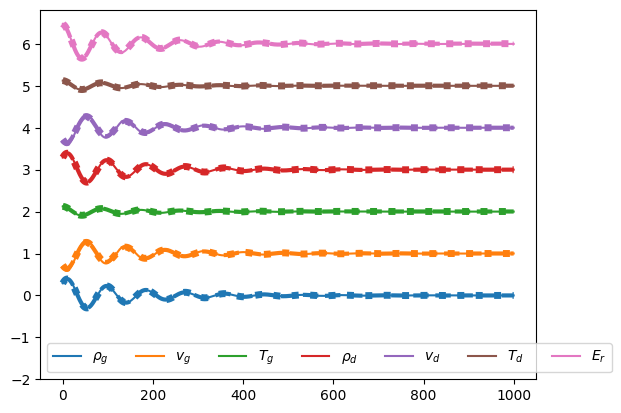

In [19]:
plot_model(1e-12, 1e-4, 1, True)

In [20]:
if True:
    for a in [1e-4, 1]:
        for rho in [1e-12, 1e-13]:
            for kappa in np.geomspace(1e-3, 1e3, 13):
                run_model(rho, a, kappa)
else:
    run_model(1e-12, 1e-4, 10**0.0)

                                  .:HMMMMHn:.  ..:n..
                                .H*'``     `'%HM'''''!x.
         :x                    x*`           .(MH:    `#h.
        x.`M                   M>        :nMMMMMMMh.     `n.
         *kXk..                XL  nnx:.XMMMMMMMMMMML   .. 4X.
          )MMMMMx              'M   `^?M*MMMMMMMMMMMM:HMMMHHMM.
          MMMMMMMX              ?k    'X ..'*MMMMMMM.#MMMMMMMMMx
         XMMMMMMMX               4:    M:MhHxxHHHx`MMx`MMMMMMMMM>
         XM!`   ?M                `x   4MM'`''``HHhMMX  'MMMMMMMM
         4M      M                 `:   *>     `` .('MX   '*MMMM'
          MX     `X.nnx..                        ..XMx`     'M*X
           ?h.    ''```^'*!Hx.     :Mf     xHMh  M**MMM      4L`
            `*Mx           `'*n.x. 4M>   :M` `` 'M    `       %
             '%                ``*MHMX   X>      !
            :!                    `#MM>  X>      `   :x
           :M                        ?M  `X     .  ..'M
           XX         


------------------------------------------------------------------------------
## WARNING in function Solve file /home/rich/Working_Copies/idefix-FLD/src/utils/iterativesolver/bicgstab.hpp line 107
Bicgstab:: Failed to converge before reaching max iter.You should consider to use a preconditionner.
------------------------------------------------------------------------------

------------------------------------------------------------------------------
## WARNING in function Solve file /home/rich/Working_Copies/idefix-FLD/src/utils/iterativesolver/bicgstab.hpp line 107
Bicgstab:: Failed to converge before reaching max iter.You should consider to use a preconditionner.
------------------------------------------------------------------------------


Bicgstab:: Reached max iter.
Bicgstab:: rho is nan in step 1.
FLD:: BICGSTAB failed, resetting radiation field
Fluid<Hydro>: Nans were found in the current calculation
Fluid<Hydro>: rank 0 found 2158 Nans in Vc in the current datablock. Details will be in corresponding process log file.
rank 0: Nan found  in variable RHO
      global (i,j,k) = (0, 0, 0)
      global (x,y,z) = (5.000000e-04, 0.000000e+00, 0.000000e+00)
rank 0: Nan found  in variable VX1
      global (i,j,k) = (0, 0, 0)
      global (x,y,z) = (5.000000e-04, 0.000000e+00, 0.000000e+00)
rank 0: Nan found  in variable PRS
      global (i,j,k) = (0, 0, 0)
      global (x,y,z) = (5.000000e-04, 0.000000e+00, 0.000000e+00)
rank 0: Nan found  in variable RHO
      global (i,j,k) = (1, 0, 0)
      global (x,y,z) = (1.500000e-03, 0.000000e+00, 0.000000e+00)
rank 0: Nan found  in variable VX1
      global (i,j,k) = (1, 0, 0)
      global (x,y,z) = (1.500000e-03, 0.000000e+00, 0.000000e+00)
rank 0: Nan found  in variable PRS
      g


------------------------------------------------------------------------------
## WARNING in function Solve file /home/rich/Working_Copies/idefix-FLD/src/utils/iterativesolver/bicgstab.hpp line 107
Bicgstab:: Failed to converge before reaching max iter.You should consider to use a preconditionner.
------------------------------------------------------------------------------


Bicgstab:: Reached max iter.


...

Bicgstab:: Reached max iter.



------------------------------------------------------------------------------
## WARNING in function Solve file /home/rich/Working_Copies/idefix-FLD/src/utils/iterativesolver/bicgstab.hpp line 107
Bicgstab:: Failed to converge before reaching max iter.You should consider to use a preconditionner.
------------------------------------------------------------------------------


TimeIntegrator:     4.767877e+01 |             2000 |     1.712219e-04 |     2.055260e+04 |             1636 |     9.393192e-13 |        99.389956
TimeIntegrator:     5.291840e+01 |             3000 |     1.150999e-02 |     2.894937e+04 |             1689 |     5.898308e-13 |        99.176308
TimeIntegrator:     6.637289e+01 |             4000 |     1.365084e-02 |     2.971907e+04 |             1410 |     9.573498e-13 |        99.145236
TimeIntegrator:     8.162751e+01 |             5000 |     1.655753e-02 |     3.191897e+04 |             1609 |     3.364375e-13 |        98.816162
TimeIntegrator:     9.805272e+01 |             6000 |     1.731475e-02 |     2.964671e+04 |             1497 |     9.664835e-13 |        99.110844
Dump: Write file n 1...done in 0.000219 s.
TimeIntegrator:     1.159786e+02 |             7000 |     1.752979e-02 |     2.970694e+04 |             1388 |     5.304791e-13 |        99.068679
TimeIntegrator:     1.346596e+02 |             8000 |     1.937995e-02 |   


------------------------------------------------------------------------------
## WARNING in function Solve file /home/rich/Working_Copies/idefix-FLD/src/utils/iterativesolver/bicgstab.hpp line 107
Bicgstab:: Failed to converge before reaching max iter.You should consider to use a preconditionner.
------------------------------------------------------------------------------


TimeIntegrator:     3.096805e+01 |             1000 |     3.102968e-02 |     2.247898e+04 |             3532 |     9.813602e-13 |        99.274386
TimeIntegrator:     6.198996e+01 |             2000 |     3.094538e-02 |     2.242079e+04 |             2568 |     5.490893e-13 |        99.240275
TimeIntegrator:     9.286904e+01 |             3000 |     3.087969e-02 |     2.264402e+04 |             2015 |     1.841317e-13 |        99.182335
Dump: Write file n 1...done in 0.000135 s.
TimeIntegrator:     1.238031e+02 |             4000 |     3.096661e-02 |     2.508936e+04 |             2327 |     4.158775e-13 |        99.176178
TimeIntegrator:     1.547045e+02 |             5000 |     3.082164e-02 |     2.376914e+04 |             2408 |     8.521225e-13 |        99.226700
TimeIntegrator:     1.855341e+02 |             6000 |     3.087190e-02 |     2.484488e+04 |             1802 |     9.722489e-13 |        99.196480
Dump: Write file n 2...done in 0.000133 s.
TimeIntegrator:     2.164297e+02

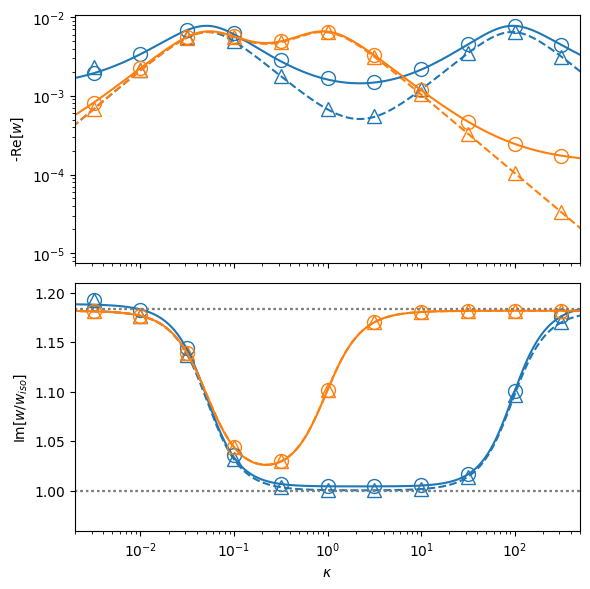

In [ ]:
def plot_eig(rho0, a0, ax, marker, **plot_args):
    kappa_an = np.geomspace(1e-3, 1e3, 1000)
    kappa_sim = np.geomspace(1e-3, 1e3, 13)

    eps = 0.1 
    a = float(a0 * (u.mm.cgs / uL).decompose()) 
    T = float(30 *u.K.cgs/uT)
    cs = np.sqrt(T/(mu*(1+eps)))

    # Plot the analytic result:
    ws = []
    for kappa0 in kappa_an: 
        kappa = float(kappa0 * ((u.cm.cgs**2/u.g.cgs) / u_opac).decompose())

        # Get the analytic solution
        RDW = RadiativeDustyWave(rho0, T, 0.1, 2.5/mu, kappa, a_d=a, eps=eps)
        ws.append(RDW.eigenvalues[RDW.eigenvalues.imag.argmax()])
    ws = np.array(ws)

    l, = ax[0].loglog(kappa_an, - ws.real, **plot_args)
    ax[1].semilogx(kappa_an, ws.imag/(2*np.pi*cs), **plot_args)

    # Plot the simulations:
    marker_args = dict(marker=marker, markerfacecolor='none', c=l.get_color(), markersize=10)
    for kappa0 in kappa_sim:
        kappa = float(kappa0 * ((u.cm.cgs**2/u.g.cgs) / u_opac).decompose())

        # Load the data
        name = get_name(rho0, a0, kappa0)
        if os.path.exists(f'out/{name}/dump.0001.dmp'):
            try:
                data = np.genfromtxt(f'out/{name}/analysis.txt')
                fit = fit_eigenvalues(data, field=1)[0]
            except:
                print(name)
                raise

            ax[0].plot(kappa0, -fit.real, **marker_args)
            ax[1].plot(kappa0, fit.imag/(2*np.pi*cs),  **marker_args)


    ax[1].axhline(1.0, ls=':', c='0.5')
    ax[1].axhline(1.4**0.5, ls=':', c='0.5')

    ax[0].set_ylabel(r'- Re[$w$]')
    ax[1].set_ylabel(r'Im[$w/w_{iso}$]')
    ax[1].set_xlabel(r'$\kappa$')

f, ax = plt.subplots(2, figsize=(6,6), sharex=True)
plot_eig(1e-13, 1e-4, ax, '^', c='C0', ls='--')
plot_eig(1e-12, 1e-4, ax, '^', c='C1', ls='--')

plot_eig(1e-13, 1.0, ax, 'o', c='C0', ls='-')
plot_eig(1e-12, 1.0, ax, 'o', c='C1', ls='-')
ax[1].set_xlim(2e-3, 5e2)
ax[1].set_ylim(ymax=1.21)

f.tight_layout()

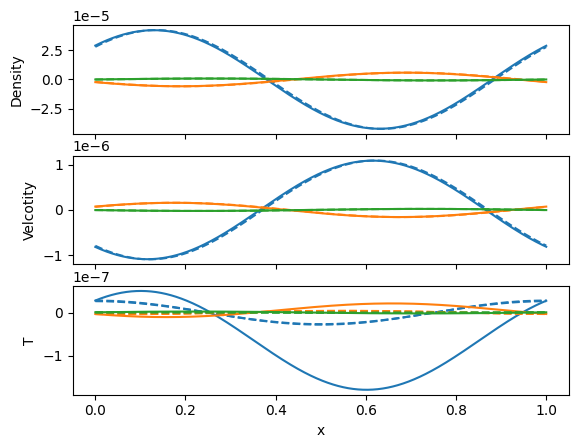

In [26]:
def plot_snap(rho0, a0, kappa0, snap, fax, **plot_args):

    fig, ax = fax
    name = get_name(rho0, a0, kappa0)
    dmp = io.readDump(f'out/{name}/dump.{snap:04d}.dmp')

    x = dmp.x1

    rho_g = dmp.data['Vc-RHO'][:,0,0] 
    rho_d = dmp.data['Dust0_Vc-RHO'][:,0,0] 

    v_g = dmp.data['Vc-VX1'][:,0,0] 
    v_d = dmp.data['Dust0_Vc-VX1'][:,0,0] 

    Tg = (mu * dmp.data['Vc-PRS'] / rho_g)[:,0,0]
    Td = (dmp.data['Dust0_Vc-TR0'])[:,0,0]
    Tr = ((dmp.data['ERAD'] / a_rad)**0.25)[:,0,0]


    kappa = float(kappa0 * ((u.cm.cgs**2/u.g.cgs) / u_opac).decompose())
    a = float(a0 * (u.mm.cgs / uL).decompose()) 
    T = float(30 *u.K.cgs/uT)
    eps = 0.1
    RDW = RadiativeDustyWave(rho0, T, 0.1, 2.5/mu, kappa, a_d=a, eps=eps)
        
    A = np.zeros(7)
    A[RDW.eigenvalues.imag.argmax()] = 1
    IC = RDW.solution(A, 0)[:,0]

    #rho0 = np.abs(IC[0])
    v0   = np.abs(IC[1])
    T0   = np.abs(IC[2])



    c = ax[0].plot(x, (rho_g-rho_g.mean())/rho0, ls='-')[0].get_color()
    ax[0].plot(x, (rho_d-rho_d.mean())/(rho0*eps), ls='--', c=c)

    ax[1].plot(x, v_g/v0, ls='-', c=c)
    ax[1].plot(x, v_d/v0, ls='--', c=c)

    ax[2].plot(x, (Tg-T)/T0, ls='-', c=c)
    ax[2].plot(x, (Td-T)/T0, ls='--', c=c)
    ax[2].plot(x, (Tr-T)/T0, ls='--', c=c)

    ax[2].set_xlabel('x')

    ax[0].set_ylabel('Density')    
    ax[1].set_ylabel('Velcotity')
    ax[2].set_ylabel('T')


#run_model(1e-12, 1.0, 1.0, 10)

f, ax = plt.subplots(3, sharex=True)
plot_snap(1e-12, 1, 1, 0, (f,ax))
plot_snap(1e-12, 1, 1, 3, (f,ax))
plot_snap(1e-12, 1, 1, 6, (f,ax))



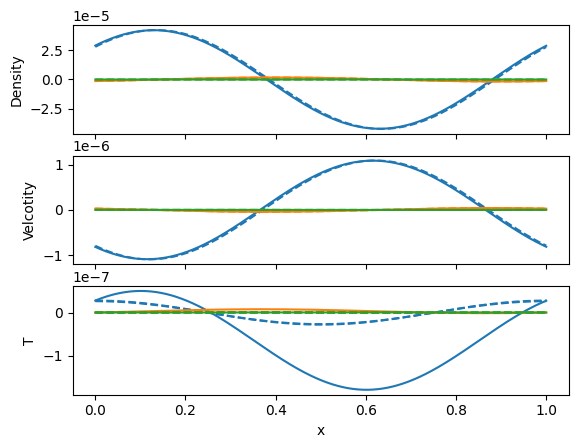

In [28]:
f, ax = plt.subplots(3, sharex=True)
plot_snap(1e-12, 1, 1, 0, (f,ax))
plot_snap(1e-12, 1, 1, 5, (f,ax))
plot_snap(1e-12, 1, 1, 10, (f,ax))